# 逻辑回归(Logistic Regression)

逻辑回归（Logistic Regression）是一种广泛应用于分类问题的统计学习方法，尽管名字中带有"回归"，但它实际上是一种用于二分类或多分类问题的算法。

逻辑回归通过使用逻辑函数（也称为 Sigmoid 函数）将线性回归的输出映射到 0 和 1 之间，从而预测某个事件发生的概率。

逻辑回归广泛应用于各种分类问题，例如：
- 邮件分类（判断邮件是否为垃圾邮件）
- 疾病预测（判断患者是否有某种疾病）
- 客户流失预测 (判断客户是否会流失)



## 逻辑回归模型
逻辑回归模型的目标是预测一个二分类结果　y∈{0,1} , 它通过建立如下的公式建立模型:
$$p(y=1|X)=\sigma(w^TX+b)$$

其中
- X 是输入特征向量(可以是多个特征组成的向量)
- $w$ 是权重向量
- $b$ 是偏置项
- $\sigma$ 是 Sigmoid 函数, 它的定义为：$\sigma(x)=\frac{1}{1+e^{-x}}$


Sigmoid 函数将模型的输出映射到 0 和 1 之间，从而将模型的输出解释为一个概率值。
其导数为：$\sigma(x)(1-\sigma(x))$ , 常用来计算梯度。


### Sigmoid 函数图像如下：
![alt text](f7cf28f9651929714345a413830f1f84.png)

### Sigmoid 函数的导数图像如下：
![alt text](516edde996590c93a09672f70960938a.png)

## 损失函数
逻辑回归的损失函数是对数损失函数（Log Loss），其形式如下：

$$J(w,b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(h_\theta(x^{(i)})) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

其中：
- $m$ 是训练样本的数量。
- $h_\theta(x) = \sigma(w^T x + b)$ 是逻辑回归的预测概率。

## 梯度下降法
和线性回归一样，逻辑回归通常也使用梯度下降法来优化损失函数，求解参数 w 和 b。逻辑回归的梯度更新规则如下：

对 $w$ 的梯度：

$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})x^{(i)}$$

对 $b$ 的梯度：

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})$$

通过不断迭代更新 $w$ 和 $b$ ，逻辑回归模型可以学习到最佳的参数，从而最小化损失函数。

----

## 使用Python实现逻辑回归模型

## 手写逻辑回归：从零开始理解训练过程

在使用 sklearn 的便利之前，我们先从零实现逻辑回归的核心部分，深入理解**如何从数据中学习参数**的过程。

### 核心步骤
1. 初始化权重 $w$ 和偏置 $b$
2. 前向传播：计算预测概率 $\hat{y} = \sigma(Xw + b)$
3. 计算损失：对数损失函数
4. 反向传播：计算梯度
5. 迭代更新：用梯度下降优化参数
6. 预测：新样本通过学到的 $w$ 和 $b$ 来分类

In [36]:
# 首先导入必要库（如果在独立环境中运行）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 配置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
iris = load_iris()
X = iris.data[:, :2]  # 只用前两个特征
y = (iris.target != 0) * 1  # 二分类

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("训练集大小:", X_train.shape)
print("测试集大小:", X_test.shape)

训练集大小: (105, 2)
测试集大小: (45, 2)


### 手写训练与预测核心

下面是逻辑回归从零实现的核心：
1. Sigmoid 函数
2. 对数损失函数
3. 梯度计算
4. 梯度下降训练
5. 概率预测与类别预测

In [37]:
class LogisticRegressionFromScratch:
    """
    手写二分类逻辑回归（梯度下降版）

    核心目标：学习参数 w, b，使对数损失最小。
    """

    def __init__(self, learning_rate=0.1, max_iter=1000, tol=1e-5, verbose=True):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        self.w = None
        self.b = None
        self.loss_history = []

    def sigmoid(self, z):
        # 数值稳定：防止 exp 溢出
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, X):
        # 线性部分 z = Xw + b，再过 sigmoid 得到概率
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def compute_loss(self, X, y):
        # 二分类交叉熵（对数损失）
        y_hat = self.forward(X)
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def compute_gradients(self, X, y):
        # 梯度推导结果：
        # dw = (1/m) * X^T(ŷ - y), db = (1/m) * sum(ŷ - y)
        y_hat = self.forward(X)
        error = y_hat - y
        m = len(y)
        dw = (1 / m) * np.dot(X.T, error)
        db = (1 / m) * np.sum(error)
        return dw, db

    def fit(self, X, y):
        # 1) 参数初始化
        self.w = np.zeros(X.shape[1], dtype=float)
        self.b = 0.0
        self.loss_history = []

        if self.verbose:
            print("开始训练手写逻辑回归...")
            print(f"learning_rate={self.learning_rate}, max_iter={self.max_iter}, tol={self.tol}")

        # 2) 迭代训练
        for i in range(self.max_iter):
            # 前向 + 反向：计算梯度
            dw, db = self.compute_gradients(X, y)

            # 参数更新（梯度下降）
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # 记录当前损失
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)

            # 按间隔打印训练日志
            if self.verbose and ((i + 1) % 100 == 0 or i == 0):
                print(f"迭代 {i + 1:4d} | loss={loss:.6f}")

            # 3) 收敛判断：相邻两次损失变化非常小
            if i > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                if self.verbose:
                    print(f"满足收敛条件，在第 {i + 1} 次迭代提前停止。")
                break

        if self.verbose:
            print("训练完成。")
        return self

    def predict_proba(self, X):
        # 返回样本属于类别 1 的概率
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        # 按阈值把概率转成类别标签
        return (self.predict_proba(X) >= threshold).astype(int)


# =========================
# 手写模型训练与评估
# =========================
model_scratch = LogisticRegressionFromScratch(
    learning_rate=0.1,
    max_iter=1000,
    tol=1e-5,
    verbose=True
)

# 训练（核心）
model_scratch.fit(X_train, y_train)

# 评估（供后续可视化/对比单元复用）
y_train_pred = model_scratch.predict(X_train)
y_test_pred = model_scratch.predict(X_test)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n手写逻辑回归结果：")
print(f"训练集准确率: {train_accuracy:.4f}")
print(f"测试集准确率: {test_accuracy:.4f}")
print(f"权重 w: {model_scratch.w}")
print(f"偏置 b: {model_scratch.b:.6f}")
print("混淆矩阵:")
print(confusion_matrix(y_test, y_test_pred))

开始训练手写逻辑回归...
learning_rate=0.1, max_iter=1000, tol=1e-05
迭代    1 | loss=0.578379
迭代  100 | loss=0.320154
迭代  200 | loss=0.224230
迭代  300 | loss=0.177396
迭代  400 | loss=0.149826
迭代  500 | loss=0.131634
迭代  600 | loss=0.118693
迭代  700 | loss=0.108991
迭代  800 | loss=0.101429
迭代  900 | loss=0.095356
迭代 1000 | loss=0.090365
训练完成。

手写逻辑回归结果：
训练集准确率: 0.9905
测试集准确率: 1.0000
权重 w: [ 2.92656328 -4.73958357]
偏置 b: -0.794234
混淆矩阵:
[[19  0]
 [ 0 26]]


/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAPH-8FED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1118425797.py:28: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAP

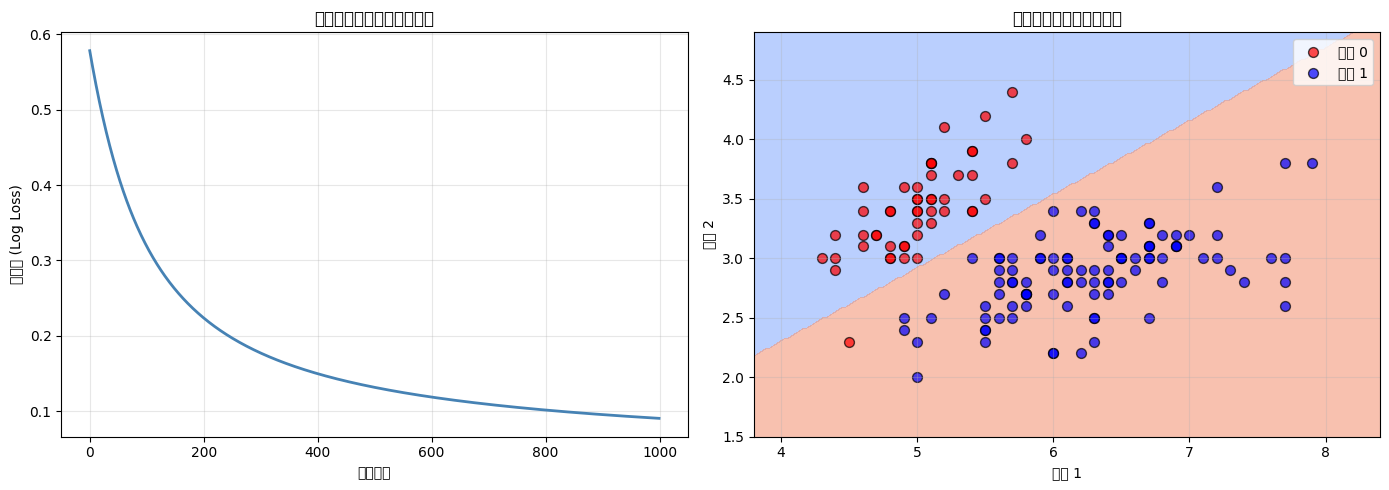

In [38]:
# 可视化：损失函数收敛过程
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失函数曲线
axes[0].plot(model_scratch.loss_history, linewidth=2, color='steelblue')
axes[0].set_title('训练过程中的损失函数变化', fontsize=12, fontweight='bold')
axes[0].set_xlabel('迭代次数')
axes[0].set_ylabel('损失值 (Log Loss)')
axes[0].grid(alpha=0.3)

# 右图：决策边界 + 数据点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), 
                      np.linspace(y_min, y_max, 200))
Z = model_scratch.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.6, cmap='coolwarm', levels=1)
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='类别 0', s=50, edgecolors='k', alpha=0.7)
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='类别 1', s=50, edgecolors='k', alpha=0.7)
axes[1].set_title('手写逻辑回归：决策边界', fontsize=12, fontweight='bold')
axes[1].set_xlabel('特征 1')
axes[1].set_ylabel('特征 2')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 对比：手写实现 vs sklearn 实现

现在让我们用 sklearn 的逻辑回归再训练一次，看看两种实现的结果是否接近。这可以验证我们的手写实现是否正确。

/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


结果对比：手写实现 vs sklearn 实现

测试集准确率:
  手写实现:    1.0000
  sklearn:    1.0000

学到的参数:
  手写实现    权重 w: [ 2.92656328 -4.73958357]
  sklearn    权重 w: [ 3.02770236 -2.7360158 ]

  手写实现    偏置 b: -0.794234
  sklearn    偏置 b: -7.521478


/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_62154/1014748264.py:60: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAP

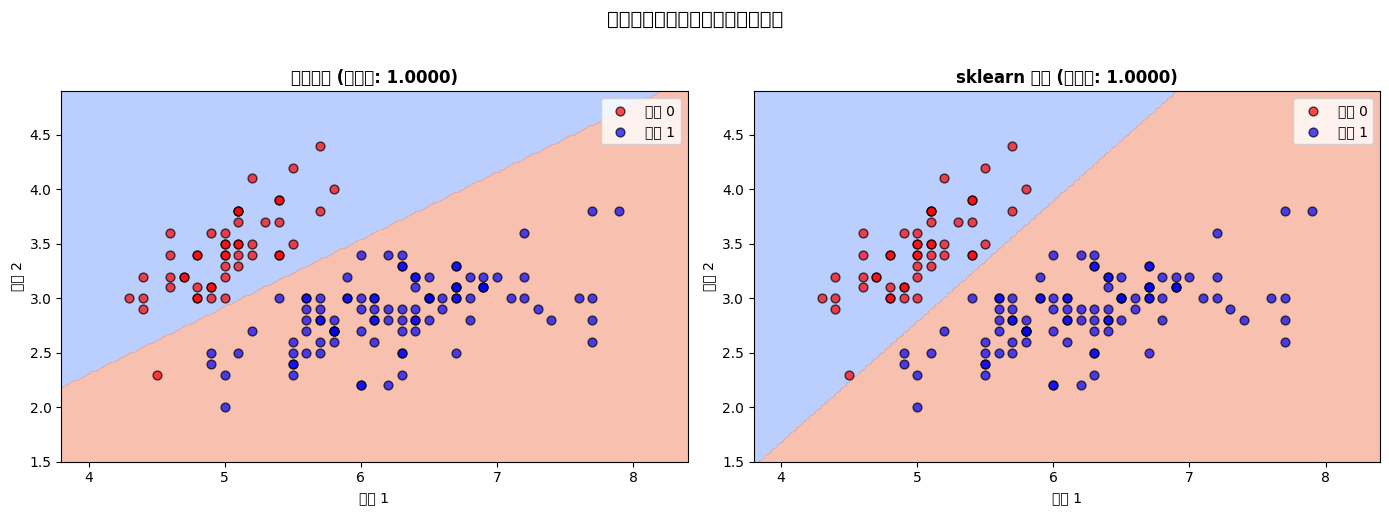


✓ 手写实现正确！两种方法学到的决策边界基本一致。


In [39]:
from sklearn.linear_model import LogisticRegression as SKLogisticRegression

# 用 sklearn 训练同样的模型
model_sklearn = SKLogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model_sklearn.fit(X_train, y_train)

# 获取 sklearn 的预测结果
y_test_pred_sklearn = model_sklearn.predict(X_test)
test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

# 对比两种实现
print("="*60)
print("结果对比：手写实现 vs sklearn 实现")
print("="*60)

print(f"\n测试集准确率:")
print(f"  手写实现:    {test_accuracy:.4f}")
print(f"  sklearn:    {test_accuracy_sklearn:.4f}")

print(f"\n学到的参数:")
print(f"  手写实现    权重 w: {model_scratch.w}")
print(f"  sklearn    权重 w: {model_sklearn.coef_[0]}")
print(f"\n  手写实现    偏置 b: {model_scratch.b:.6f}")
print(f"  sklearn    偏置 b: {model_sklearn.intercept_[0]:.6f}")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), 
                      np.linspace(y_min, y_max, 200))

# 左图：手写实现的决策边界
Z_scratch = model_scratch.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z_scratch, alpha=0.6, cmap='coolwarm', levels=1)
axes[0].scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='类别 0', s=40, edgecolors='k', alpha=0.7)
axes[0].scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='类别 1', s=40, edgecolors='k', alpha=0.7)
axes[0].set_title(f'手写实现 (准确率: {test_accuracy:.4f})', fontweight='bold')
axes[0].set_xlabel('特征 1')
axes[0].set_ylabel('特征 2')
axes[0].legend()

# 右图：sklearn 的决策边界
Z_sklearn = model_sklearn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_sklearn, alpha=0.6, cmap='coolwarm', levels=1)
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='类别 0', s=40, edgecolors='k', alpha=0.7)
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='类别 1', s=40, edgecolors='k', alpha=0.7)
axes[1].set_title(f'sklearn 实现 (准确率: {test_accuracy_sklearn:.4f})', fontweight='bold')
axes[1].set_xlabel('特征 1')
axes[1].set_ylabel('特征 2')
axes[1].legend()

plt.suptitle('决策边界对比：两种实现基本一致', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ 手写实现正确！两种方法学到的决策边界基本一致。")

## 深度理解：梯度下降的每一步

让我们通过一个简单例子来看梯度是如何驱动参数更新的。

In [40]:
# 手工演示梯度下降的前几步
print("="*60)
print("梯度下降演示：前 5 步")
print("="*60)

# 重新初始化
w_demo = np.zeros(X_train.shape[1])
b_demo = 0

def sigmoid_demo(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_loss_demo(X, y, w, b):
    y_pred = sigmoid_demo(np.dot(X, w) + b)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -1/len(y) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return loss

print("\n初始状态:")
print(f"  w = {w_demo}, b = {b_demo}")
print(f"  损失 = {compute_loss_demo(X_train, y_train, w_demo, b_demo):.6f}")

# 手动执行前 5 次迭代
learning_rate = 0.1
for step in range(5):
    # 前向传播
    z = np.dot(X_train, w_demo) + b_demo
    y_pred_demo = sigmoid_demo(z)
    
    # 计算梯度
    error = y_pred_demo - y_train
    dw = 1/len(y_train) * np.dot(X_train.T, error)
    db = 1/len(y_train) * np.sum(error)
    
    # 更新参数
    w_demo -= learning_rate * dw
    b_demo -= learning_rate * db
    
    # 计算新的损失
    loss = compute_loss_demo(X_train, y_train, w_demo, b_demo)
    
    print(f"\n第 {step + 1} 步:")
    print(f"  梯度 dw = {dw}, db = {db:.6f}")
    print(f"  参数更新: w = {w_demo}, b = {b_demo:.6f}")
    print(f"  损失 = {loss:.6f} ↓ (下降)")

print("\n" + "="*60)
print("总结：每一步梯度都指向损失函数下降的方向")
print("  w -= learning_rate * dw  （参数沿梯度反方向更新）")
print("  b -= learning_rate * db  （学习率控制步长大小）")
print("="*60)

梯度下降演示：前 5 步

初始状态:
  w = [0. 0.], b = 0
  损失 = 0.693147

第 1 步:
  梯度 dw = [-1.45571429 -0.50761905], db = -0.204762
  参数更新: w = [0.14557143 0.0507619 ], b = 0.020476
  损失 = 0.578379 ↓ (下降)

第 2 步:
  梯度 dw = [-0.0633302   0.20108404], db = 0.030268
  参数更新: w = [0.15190445 0.0306535 ], b = 0.017449
  损失 = 0.573922 ↓ (下降)

第 3 步:
  梯度 dw = [-0.09278273  0.18463002], db = 0.025033
  参数更新: w = [0.16118272 0.0121905 ], b = 0.014946
  损失 = 0.569604 ↓ (下降)

第 4 步:
  梯度 dw = [-0.09640446  0.18141571], db = 0.024188
  参数更新: w = [ 0.17082317 -0.00595107], b = 0.012527
  损失 = 0.565337 ↓ (下降)

第 5 步:
  梯度 dw = [-0.09645091  0.18003975], db = 0.023951
  参数更新: w = [ 0.18046826 -0.02395505], b = 0.010132
  损失 = 0.561121 ↓ (下降)

总结：每一步梯度都指向损失函数下降的方向
  w -= learning_rate * dw  （参数沿梯度反方向更新）
  b -= learning_rate * db  （学习率控制步长大小）


## 手写实现核心步骤总结

### 1. **Sigmoid 函数**
```
σ(z) = 1 / (1 + e^(-z))
```
- 将任意实数映射到 (0, 1)，表示概率
- 导数：σ'(z) = σ(z) * (1 - σ(z))

### 2. **前向传播（预测）**
```
z = Xw + b
ŷ = σ(z)  → 预测概率
```

### 3. **损失函数（对数损失）**
$$J = -\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})]$$

### 4. **反向传播（梯度计算）**
- 梯度 dw：每个特征对损失的贡献
- 梯度 db：偏置对损失的贡献
```
dw = (1/m) * X^T(ŷ - y)
db = (1/m) * Σ(ŷ - y)
```

### 5. **参数更新（梯度下降）**
```
w := w - learning_rate * dw
b := b - learning_rate * db
```

### 6. **收敛判定**
- 监控损失函数值
- 相邻迭代损失变化 < 容差 → 收敛

---

## 关键洞察

| 概念 | 含义 |
|------|------|
| **Sigmoid** | 把线性输出变成概率 |
| **梯度** | 参数对损失的影响方向和大小 |
| **学习率** | 控制每次参数更新的步长 |
| **损失下降** | 表明模型在学习，参数在优化 |
| **收敛** | 参数基本不再变化，停止训练 |

---

## 应用场景

- ✓ 邮件分类（是/否垃圾邮件）
- ✓ 疾病预测（患病/未患病）
- ✓ 用户流失预测（流失/保留）
- ✓ 信用评分（借款人是否违约）
- ✓ 点击率预测（用户是否点击广告）

---

## 优缺点

**优点：**
- 思想简单，计算快
- 结果可解释（概率输出）
- 对异常值鲁棒

**缺点：**
- 只能处理线性可分的问题
- 多分类需要一对多策略
- 对特征缩放敏感

In [41]:
# 1. 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report       # accuracy_score 计算准确率 , confusion_matrix 混淆矩阵 , classification_report 分类报告


In [42]:
# 2. 加载数据集
iris = load_iris()
X = iris.data[:, :2]     # 只使用前两个特征
y = (iris.target != 0) * 1      # 将目标变量转换为二分类问题


# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
# 3. 训练逻辑回归模型
# 初始化逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
# 4. 评估模型

# 预测测试集
y_pred = model.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"准确率: {accuracy:.4f}")

# 计算混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(conf_matrix)


# 生成分类报告
class_report = classification_report(y_test, y_pred)
print("分类报告:")
print(class_report)


准确率: 1.0000
混淆矩阵:
[[19  0]
 [ 0 26]]
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        26

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



[[3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 ...
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]]
(440, 560)


[3.3  3.31 3.32 ... 8.87 8.88 8.89]
(246400,)


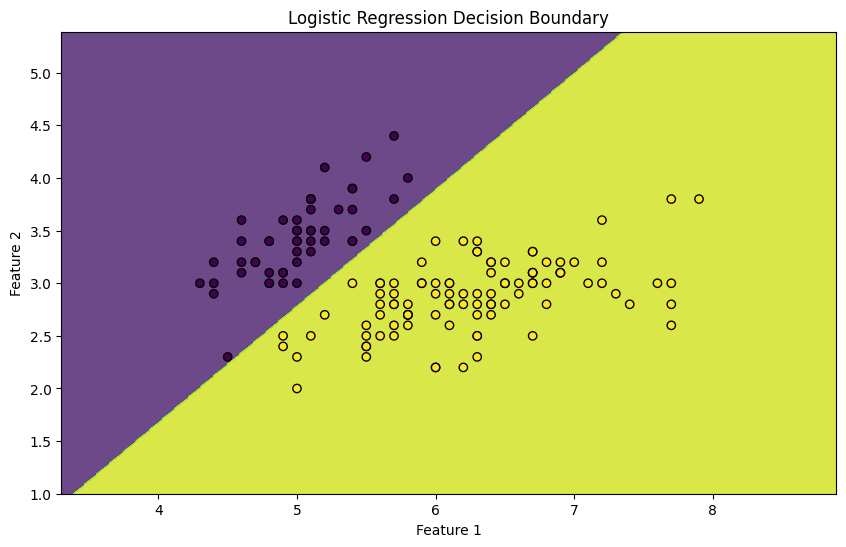

In [45]:
# 5. 可视化决策边界
plt.figure(figsize=(10, 6))

x_min , x_max = X[: , 0].min() - 1 , X[: , 0].max() + 1
y_min , y_max = X[: , 1].min() - 1 , X[: , 1].max() + 1

xx , yy = np.meshgrid(np.arange(x_min , x_max , step=0.01) , np.arange(y_min , y_max , step=0.01))      # meshgrid 生成网格点
print(xx)
print(xx.shape)
print("\n")
print(xx.ravel())
print(xx.ravel().shape)
Z = model.predict(np.c_[xx.ravel() , yy.ravel()])           # 对网格上的每个点进行预测 , np.c_ 合并 xx 和 yy 的 ravel() 方法，将它们转换为一维数组，用于模型预测
Z = Z.reshape(xx.shape)

plt.contourf(xx , yy , Z , alpha=0.8)
plt.scatter(X[: , 0] , X[: , 1] , c=y ,edgecolors='k', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

### 总结
- 逻辑回归通过使用Sigmoid函数将线性回归的输出转换为概率值，用于解决二分类问题。
- 逻辑回归的训练过程通过最小化损失函数来优化模型参数
- 梯度下降法是常用的优化方法 , 用来更新模型参数 $w$ 和 $b$
- Python中的scikit-learn库提供了简单易用的接口来实现逻辑回归，并且能够轻松地进行模型训练、评估和可视化。
